In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sunil123kumar/social-media-impact-on-mental-health/Teen_Mental_Health_Dataset.csv


https://www.kaggle.com/datasets/sunil123kumar/social-media-impact-on-mental-health

In [2]:
# Loading Dataset
data = pd.read_csv('/kaggle/input/datasets/sunil123kumar/social-media-impact-on-mental-health/Teen_Mental_Health_Dataset.csv')

## 1. Understanding Data

In [3]:
# Converting data into DataFrame
df = pd.DataFrame(data)

In [4]:
df.shape

(1200, 13)

In [5]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1200.0,15.928333,2.021947,13.0,14.0,16.00,18.00,19.0
daily_social_media_hours,1200.0,4.536667,2.029599,1.0,2.8,4.50,6.30,8.0
sleep_hours,1200.0,6.449417,1.442677,4.0,5.2,6.50,7.60,9.0
screen_time_before_sleep,1200.0,1.740333,0.716660,0.5,1.1,1.80,2.40,3.0
academic_performance,1200.0,2.990383,0.576758,2.0,2.5,2.99,3.48,4.0
physical_activity,1200.0,1.014500,0.582185,0.0,0.5,1.00,1.50,2.0
stress_level,1200.0,5.445833,2.903290,1.0,3.0,5.00,8.00,10.0
anxiety_level,1200.0,5.636667,2.859453,1.0,3.0,6.00,8.00,10.0
addiction_level,1200.0,5.565000,2.830627,1.0,3.0,6.00,8.00,10.0
depression_label,1200.0,0.025833,0.158704,0.0,0.0,0.00,0.00,1.0


Above shows that our data contains no extreme values

In [8]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.nunique()

age                           7
gender                        2
daily_social_media_hours     71
platform_usage                3
sleep_hours                  51
screen_time_before_sleep     26
academic_performance        201
physical_activity            21
social_interaction_level      3
stress_level                 10
anxiety_level                10
addiction_level              10
depression_label              2
dtype: int64

In [11]:
df.corr(numeric_only=True)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
age,1.000000,-0.006635,0.001530,0.075612,-0.013973,0.011086,-0.031208,0.026363,0.038265,0.010973
daily_social_media_hours,-0.006635,1.000000,-0.009472,0.035777,0.013179,0.025546,0.030698,0.027835,-0.024964,0.175201
sleep_hours,0.001530,-0.009472,1.000000,0.010235,0.021866,0.012701,-0.010979,-0.011879,-0.054838,-0.190630
screen_time_before_sleep,0.075612,0.035777,0.010235,1.000000,-0.034715,-0.026450,-0.008650,-0.010344,0.028884,-0.016502
academic_performance,-0.013973,0.013179,0.021866,-0.034715,1.000000,0.023312,-0.000600,-0.064379,0.029354,0.001441
physical_activity,0.011086,0.025546,0.012701,-0.026450,0.023312,1.000000,0.012159,-0.022233,0.026200,-0.017598
stress_level,-0.031208,0.030698,-0.010979,-0.008650,-0.000600,0.012159,1.000000,0.015811,-0.000129,0.170474
anxiety_level,0.026363,0.027835,-0.011879,-0.010344,-0.064379,-0.022233,0.015811,1.000000,0.031154,0.169566
addiction_level,0.038265,-0.024964,-0.054838,0.028884,0.029354,0.026200,-0.000129,0.031154,1.000000,-0.013952
depression_label,0.010973,0.175201,-0.190630,-0.016502,0.001441,-0.017598,0.170474,0.169566,-0.013952,1.000000


In [12]:
# Returns the relative percentages (e.g., 0.50 instead of 500)
df['depression_label'].value_counts(normalize=True)

depression_label
0    0.974167
1    0.025833
Name: proportion, dtype: float64

## 2. Data Cleaning

In [13]:
# Renaming columns to make it more readable
df = df.rename(columns = {'screen_time_before_sleep' : 'bedtime_scroll','physical_activity' : 'activity_hrs'})

In [14]:
# Converting datatype
float_cols = df.select_dtypes(include=['float64']).columns
df[float_cols] = df[float_cols].round(2)

df[float_cols].head()

,daily_social_media_hours,sleep_hours,bedtime_scroll,academic_performance,activity_hrs
0,7.9,7.4,2.9,3.01,1.5
1,1.9,8.0,2.9,3.22,0.8
2,1.3,7.6,0.5,3.92,0.0
3,7.4,6.9,1.6,3.48,0.8
4,4.7,4.9,3.0,2.37,1.4


#### Roundng doesn't make a huge impact but for brevity(making data simple) I have done it

In [15]:
# Converting text columns to lowercase
text_cols = df.select_dtypes(include=['object', 'string']).columns
df[text_cols] = df[text_cols].apply(lambda x: x.str.lower())

#### Normalize text casing to prevent data fragmentation.

## 3. EDA

### 3.1 Univariate Analysis

<Axes: xlabel='age', ylabel='Count'>

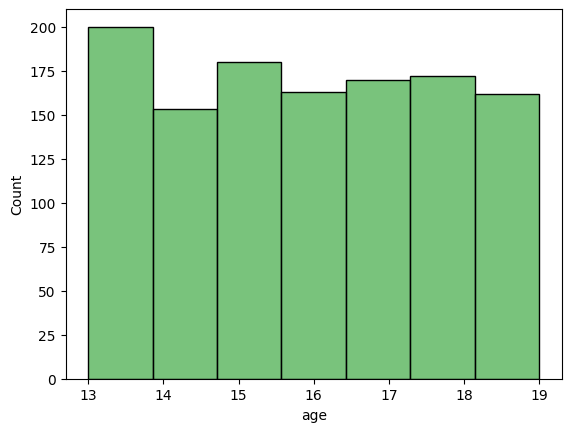

In [16]:
sns.histplot(df['age'],bins=7,color='#4CAF50',edgecolor='black')

#### **Key Observation: Non-Normal Distribution**
* **Shape:** The plot displays a flat, uniform distribution rather than a traditional bell curve.
* **Cause:** The data isolates a specific age range (13–19 years old). 
* **Insight:** Every age year within this specific cohort is almost equally represented in the dataset.


In [17]:
df['age'].value_counts().sort_index().to_numpy().reshape(1, -1) 

array([[200, 153, 180, 163, 170, 172, 162]])

Starting from 13 till 19

Text(0.5, 1.0, 'Distribution of Gender')

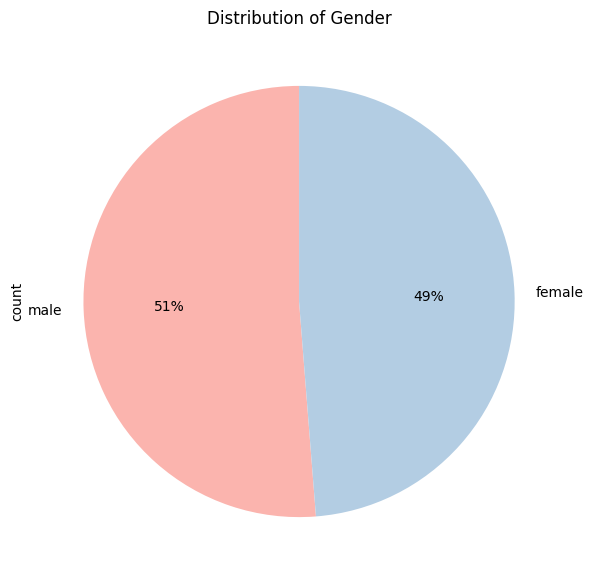

In [18]:
# Getting the counts of each different Watering Frequencies
Smoking_Status_counts = df['gender'].value_counts()
fig,ax = plt.subplots(figsize=(7,7))

Smoking_Status_counts.plot.pie(
    ax=ax,
    autopct='%1.0f%%',  # For percentage
    startangle=90,      # For better view
    colors=plt.get_cmap('Pastel1').colors  # For Colors

)

ax.set_title('Distribution of Gender')

This shows data is **not** biased towards one gender

Text(0.5, 1.0, 'Distribution of daily_social_media_hours')

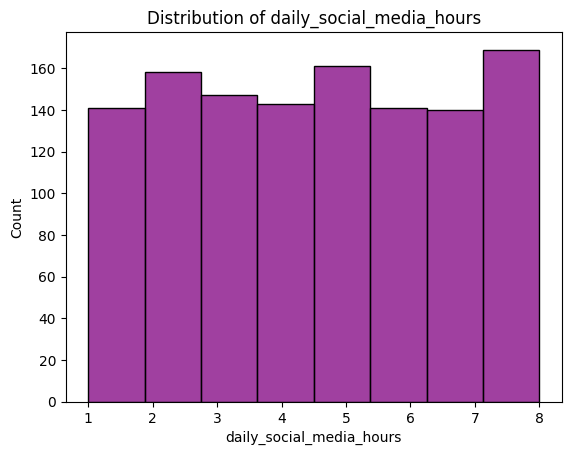

In [19]:
sns.histplot(df['daily_social_media_hours'],bins=8,color='purple',edgecolor='black')
plt.title('Distribution of daily_social_media_hours')

##### Users in this dataset are almost equally likely to spend 1 hour online as they are to spend 4, 6, or 8 hours.

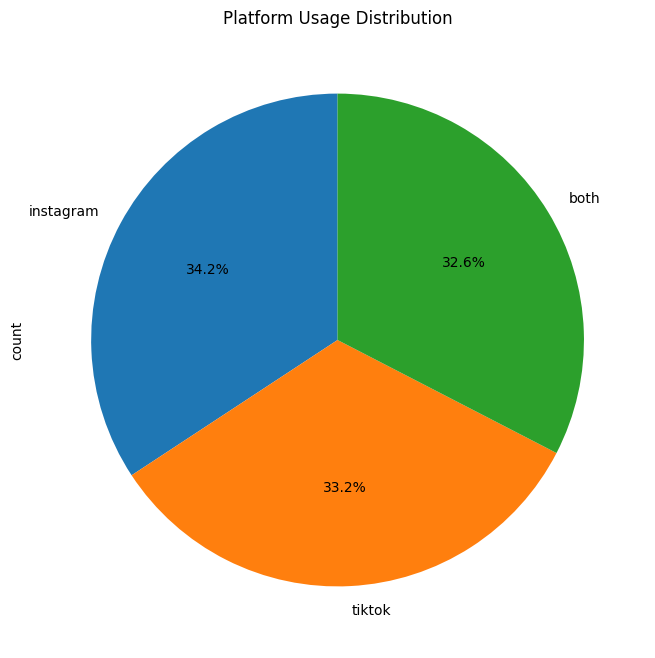

In [20]:
plt.figure(figsize=(8,8))
df["platform_usage"].value_counts().plot.pie(
    autopct="%1.1f%%",
    startangle=90,
    shadow=False
)
plt.title("Platform Usage Distribution")
plt.show()

THis shows our data is almost equally distributed 

<Axes: xlabel='sleep_hours', ylabel='Count'>

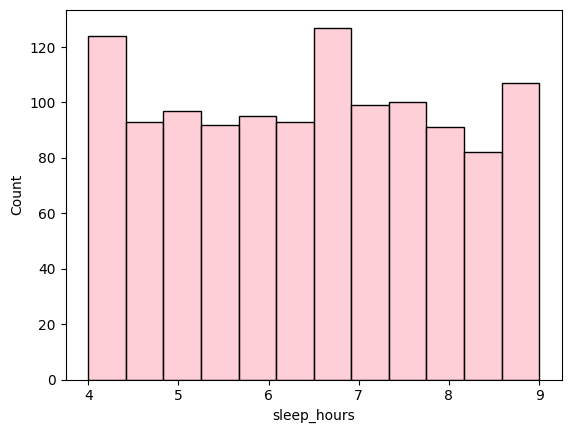

In [21]:
sns.histplot(df['sleep_hours'],color='pink',edgecolor='black')


<Axes: xlabel='bedtime_scroll', ylabel='Count'>

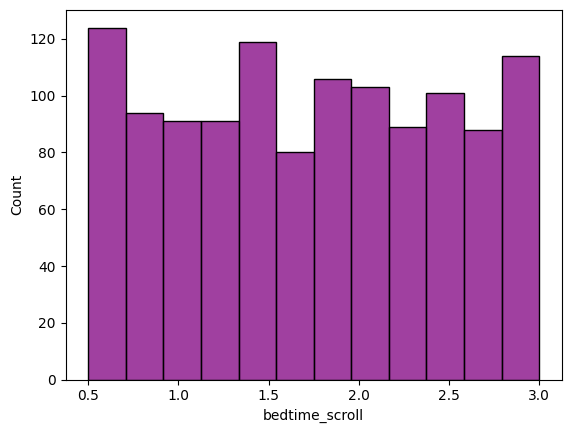

In [22]:
sns.histplot(df['bedtime_scroll'],color='purple',edgecolor='black')

<Axes: xlabel='academic_performance', ylabel='Count'>

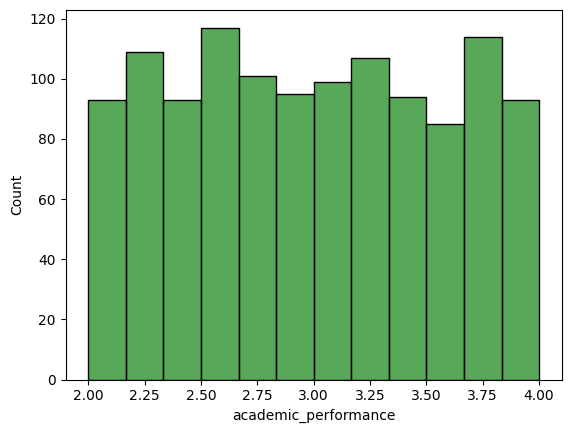

In [23]:
sns.histplot(df['academic_performance'],color='forestgreen',edgecolor='black')

<Axes: xlabel='activity_hrs', ylabel='Count'>

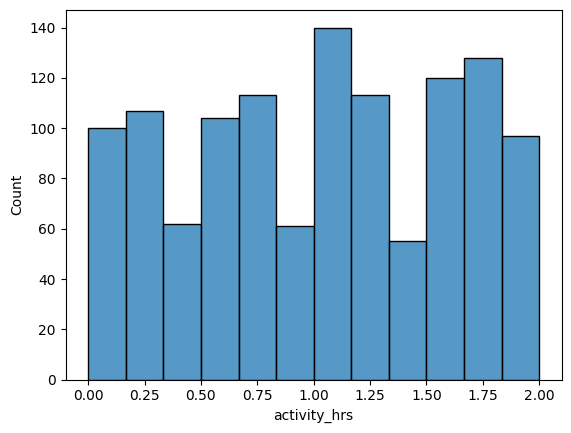

In [24]:
sns.histplot(df['activity_hrs'],edgecolor='black')

Text(0.5, 1.0, 'Distribution of social_interaction_level')

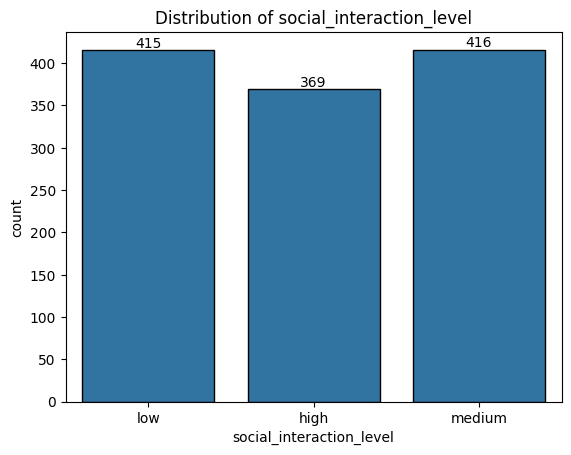

In [25]:
# 1. Save the plot into an axis variable 'ax'
ax = sns.countplot(x=df['social_interaction_level'], edgecolor='black')

# 2. Automatically compute and display the value numbers on top of each bar
ax.bar_label(ax.containers[0])

plt.title("Distribution of social_interaction_level")

<Axes: xlabel='stress_level', ylabel='Count'>

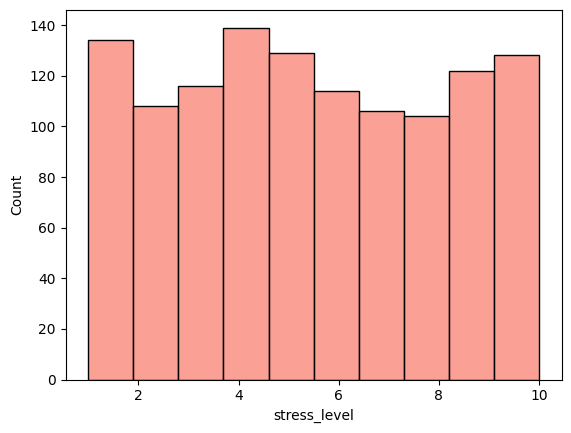

In [26]:
sns.histplot(df['stress_level'],bins=10,color='salmon',edgecolor='black')

<Axes: xlabel='anxiety_level', ylabel='Count'>

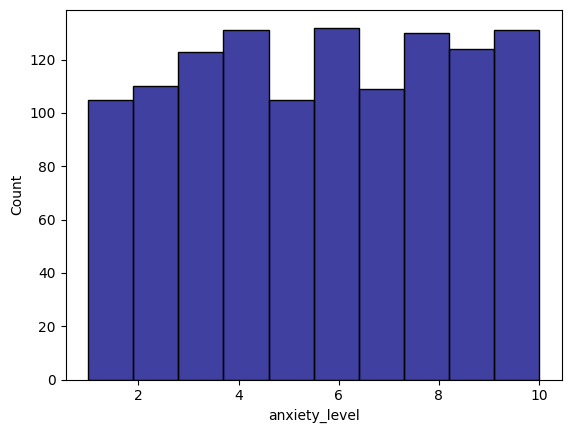

In [27]:
sns.histplot(df['anxiety_level'],bins=10,color='navy',edgecolor='black')

<Axes: xlabel='addiction_level', ylabel='Count'>

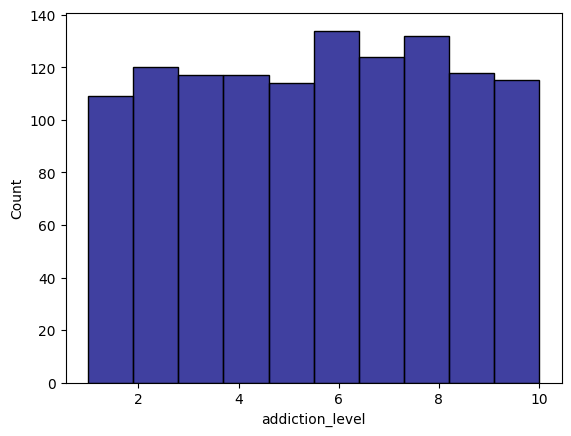

In [28]:
sns.histplot(df['addiction_level'],bins=10,color='navy',edgecolor='black')

Text(0.5, 1.0, 'Distribution of Depression Level')

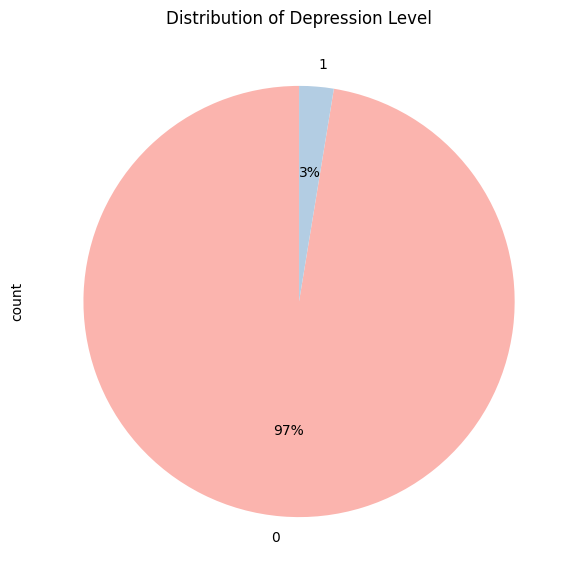

In [29]:
# Getting the counts of each different Watering Frequencies
Smoking_Status_counts = df['depression_label'].value_counts()
fig,ax = plt.subplots(figsize=(7,7))

Smoking_Status_counts.plot.pie(
    ax=ax,
    autopct='%1.0f%%',  # For percentage
    startangle=90,      # For better view
    colors=plt.get_cmap('Pastel1').colors  # For Colors

)

ax.set_title('Distribution of Depression Level')

### 3.2 Bivariate Distribution

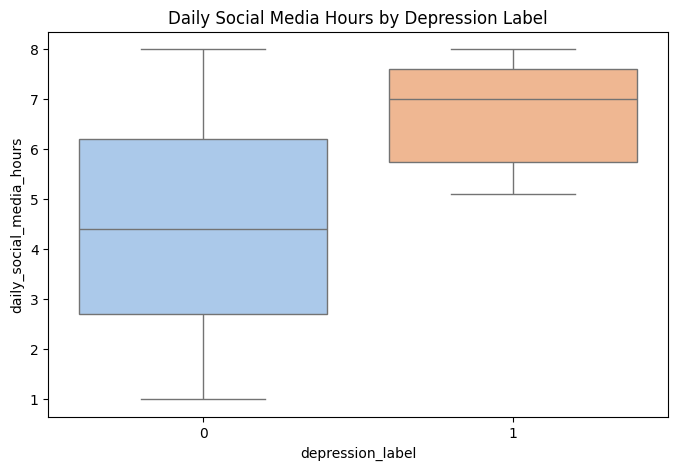

In [30]:
# Boxplot comparing daily social media hours across depression labels
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x='depression_label',
    y='daily_social_media_hours',
    hue='depression_label',
    palette='pastel',
    legend=False
)
plt.title('Daily Social Media Hours by Depression Label')
plt.show()

Reason for plotting : To see how continuous social media usage behaves across discrete depression categories.

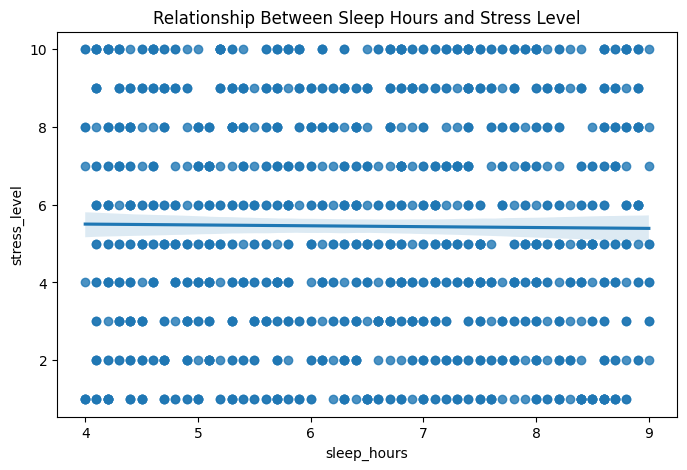

In [31]:
# Scatter plot mapping sleep hours against stress levels with a trend line
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='sleep_hours', y='stress_level')
plt.title('Relationship Between Sleep Hours and Stress Level')
plt.show()


Sleep hours and Stress level  have a very weak negative relationship.

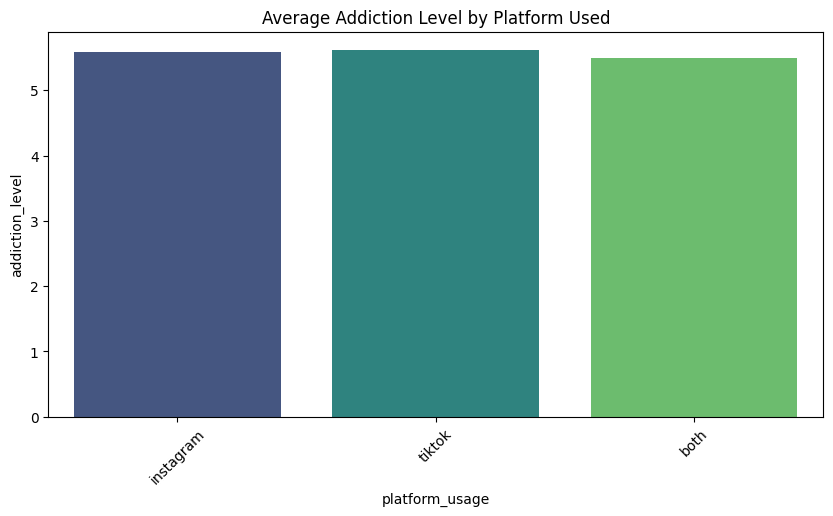

In [32]:
# Cell 3: Bar plot showing average addiction levels for each social media platform
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x='platform_usage',
    y='addiction_level',
    hue='platform_usage',
    palette='viridis',
    errorbar=None,
    legend=False
)

plt.title('Average Addiction Level by Platform Used')
plt.xticks(rotation=45)
plt.show()


So individual platform user and both platform users are addited 

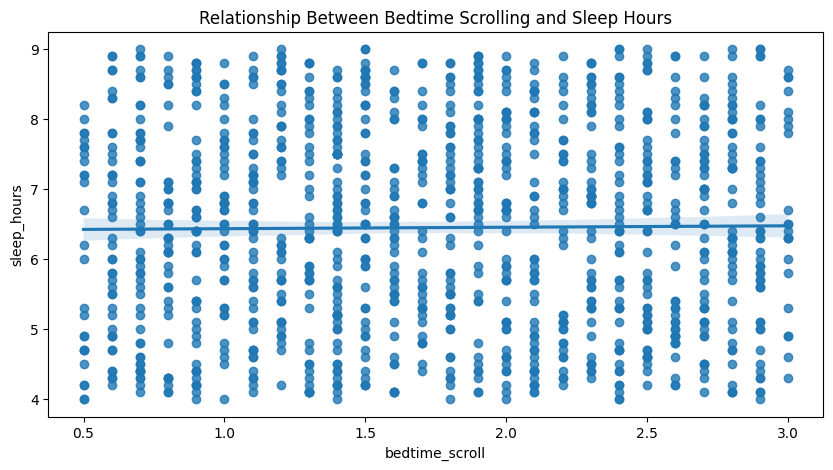

In [33]:
plt.figure(figsize=(10,5))

sns.regplot(
    data=df,
    x='bedtime_scroll',
    y='sleep_hours'
)

plt.title('Relationship Between Bedtime Scrolling and Sleep Hours')
plt.show()

Sleep hours and bed time school have little positive correlation

### 3.3 Multivariate Analysis

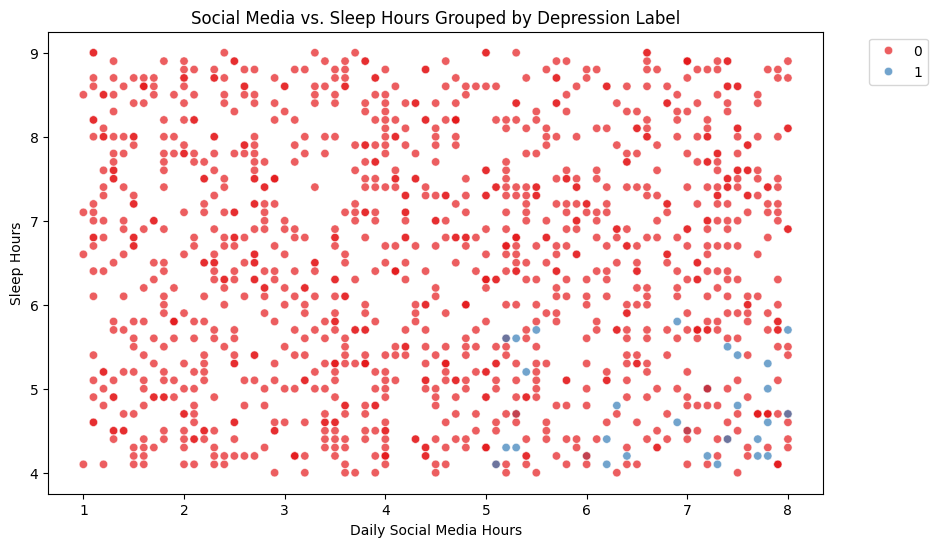

In [34]:
# 3-Variable Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='daily_social_media_hours', 
    y='sleep_hours', 
    hue='depression_label', 
    alpha=0.7,
    palette='Set1'
)
plt.title('Social Media vs. Sleep Hours Grouped by Depression Label')
plt.xlabel('Daily Social Media Hours')
plt.ylabel('Sleep Hours')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


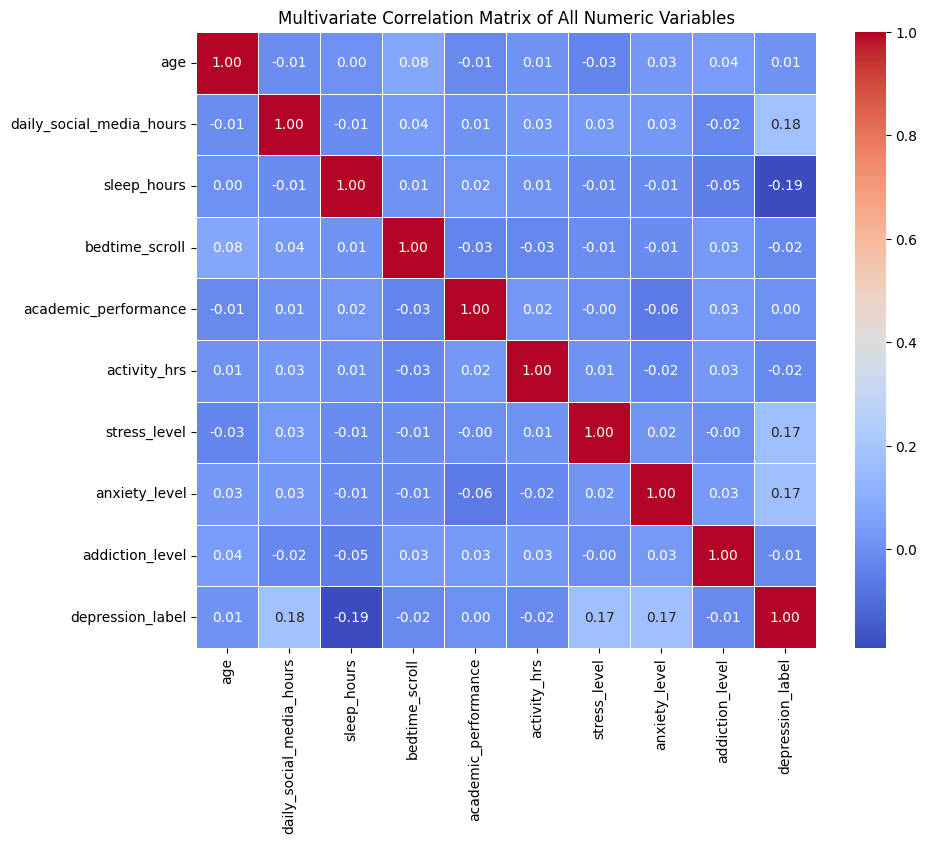

In [35]:
# Complete Correlation Heatmap
plt.figure(figsize=(10, 8))

# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=['number'])
correlation_matrix = numeric_cols.corr()

# Draw the heatmap
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5
)
plt.title('Multivariate Correlation Matrix of All Numeric Variables')
plt.show()


## 4. Data Preprocessing

In [36]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split


In [37]:
# Implementing OneHotEncoding -> Converting Categorical to numeric
df = pd.get_dummies(data=df,columns=['gender','platform_usage','social_interaction_level'],drop_first = True,dtype=int)
df.head()

,age,daily_social_media_hours,sleep_hours,bedtime_scroll,academic_performance,activity_hrs,stress_level,anxiety_level,addiction_level,depression_label,gender_male,platform_usage_instagram,platform_usage_tiktok,social_interaction_level_low,social_interaction_level_medium
0,14,7.9,7.4,2.9,3.01,1.5,2,2,1,0,1,1,0,1,0
1,19,1.9,8.0,2.9,3.22,0.8,8,1,10,0,0,0,1,0,0
2,17,1.3,7.6,0.5,3.92,0.0,2,4,2,0,0,1,0,0,0
3,15,7.4,6.9,1.6,3.48,0.8,1,7,9,0,1,0,1,0,1
4,15,4.7,4.9,3.0,2.37,1.4,3,5,2,0,0,0,0,0,1


In [38]:
# Splitting data so test data remained untouched
X = df.drop("depression_label", axis=1)
y = df["depression_label"]

In [39]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [40]:
df.shape

(1200, 15)

In [41]:
# Implement StandardScaler to eliminate scaling bias across numerical features.

all_numeric_cols  = df.select_dtypes(include='number').columns # keep only non-binary numeric columns and scale them

cols_to_scale  = [c for c in all_numeric_cols  if df[c].nunique() > 2]

scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Transform ONLY if using fit_transform so X_test uses it's own mean value
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [42]:
X_train_df = pd.DataFrame(X_train)
X_train_df.head()

,age,daily_social_media_hours,sleep_hours,bedtime_scroll,academic_performance,activity_hrs,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_instagram,platform_usage_tiktok,social_interaction_level_low,social_interaction_level_medium
331,0.020422,0.766421,1.135845,-0.476546,0.476375,1.029629,1.564665,-1.598783,-0.553219,0,1,0,1,0
409,-0.469701,0.569455,0.720924,0.915253,-0.268164,0.513021,1.564665,1.560029,-1.256185,0,1,0,0,1
76,-1.449946,-1.695645,0.444311,0.080173,-0.770295,-0.347993,-0.141854,-0.194867,1.555678,1,0,1,0,0
868,0.020422,0.372490,-1.491985,-0.337366,-0.787610,-1.209007,0.540753,0.507092,1.555678,0,0,1,0,0
138,-0.959824,0.914145,-0.316377,-0.894086,1.411378,-0.175790,0.882057,-1.247804,-0.904702,0,1,0,0,1


## 5. Model Selection & Hyperparameter Tuning

In [43]:
from sklearn.model_selection import KFold

In [44]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

## 6. Machine Learning

In [45]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#### Instead of writing each model code separately we're using dictonary and later will pass into loop.

In [46]:
models = {
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC()
}

In [47]:
# Multiple Parameters of each model to find out the best one
param_grids = {
    "KNN": {
        "n_neighbors": [3, 5, 7, 9],
        "weights": ["uniform", "distance"]
    },

    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["liblinear", "lbfgs"]
    },

    "Decision Tree": {
        "max_depth": [None, 5, 10, 15],
        "min_samples_split": [2, 5, 10]
    },

    "SVM": {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"]
    }
}

In [48]:
results = {} # Stores the best parameter and accuracy of each model after traning on all the parameters given in 'param_grids' 
best_models = {} # Stores the object of each model so that we can choose the best one for prediction

for name, model in models.items():

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=kf,
        scoring='accuracy',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    results[name] = {
        "Best Params": grid.best_params_,
        "Best CV Score": grid.best_score_
    }

    best_models[name] = grid # Storing object
    
    print(f"\n{name}")
    print("Best Params:", grid.best_params_)
    print("Best CV Score:", grid.best_score_)


KNN
Best Params: {'n_neighbors': 5, 'weights': 'uniform'}
Best CV Score: 0.978125

Logistic Regression
Best Params: {'C': 1, 'solver': 'liblinear'}
Best CV Score: 0.9822916666666668

Decision Tree
Best Params: {'max_depth': None, 'min_samples_split': 2}
Best CV Score: 0.996875

SVM
Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Score: 0.9895833333333333


In [49]:
# DataFram of results to make it more readable
results_df = pd.DataFrame(results)
results_df

,KNN,Logistic Regression,Decision Tree,SVM
Best Params,"{'n_neighbors': 5, 'weights': 'uniform'}","{'C': 1, 'solver': 'liblinear'}","{'max_depth': None, 'min_samples_split': 2}","{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}"
Best CV Score,0.978125,0.982292,0.996875,0.989583


In [50]:
best_model_name = max(
    results,
    key=lambda x: results[x]["Best CV Score"]
)

print("Best Model:", best_model_name)

Best Model: Decision Tree


In [51]:
'''We can also directly writes the best model nam by referring above DataFrame instead of creating a variable'''
best_grid = best_models[best_model_name] # Returns the best model object

In [52]:
best_estimator = best_grid.best_estimator_  # This is the actual trained classifier.

In [53]:
# Predict 
y_pred = best_estimator.predict(X_test)

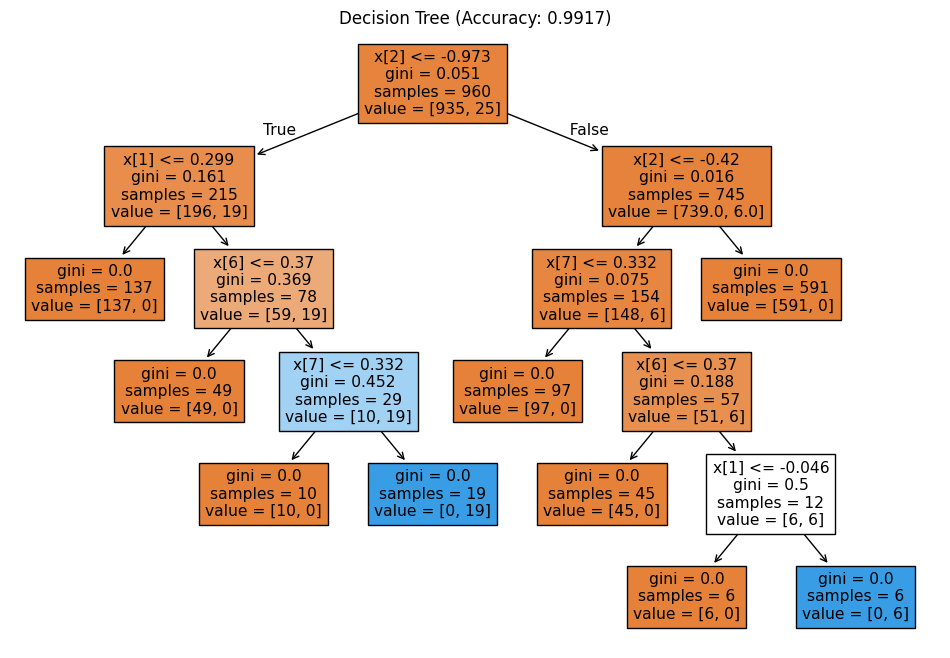

In [54]:
from sklearn import tree
plt.figure(figsize=(12, 8))
tree.plot_tree(best_estimator, filled=True)
plt.title(f"Decision Tree (Accuracy: {accuracy_score(y_test, y_pred):.4f})")
plt.show()

In [55]:
print("Test Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Test Accuracy: 0.9916666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       0.83      0.83      0.83         6

    accuracy                           0.99       240
   macro avg       0.91      0.91      0.91       240
weighted avg       0.99      0.99      0.99       240



## 7. Key Insight

**Even though the overall accuracy is very high (99%), the dataset is highly imbalanced, with class 1 having very few samples. Because of this:**

* The model is heavily influenced by class 0
* Performance on class 1 is less stable due to limited data
* Accuracy alone is not a sufficient metric here

#### I spent 5h 38 minutes hours working on this notebook, and as a beginner, I learned a lot of new things.

### Please Upvote me if you like my work :)